# Siamese network đơn giản cho chữ ký

CNN tự xây (3 lớp Conv2D), dùng chung trọng số cho Anchor, Positive và Negative. Train bằng **triplet loss**; test bằng khoảng cách giữa hai embedding.

Chạy **Run All** từ thư mục chứa notebook này, `datapreprocessing.ipynb` và `dataset/`. Cần `tensorflow`, `numpy`, `matplotlib`, `scikit-learn`. Không dùng model pretrained hoặc hard-negative mining.


In [1]:
import json
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Dùng lại 4 cell đầu: imports, cấu hình, chia writers, hàm tạo triplet.
# Không chạy cell demo chỉ có 2 mẫu trong notebook gốc.
with Path("datapreprocessing.ipynb").open(encoding="utf-8") as f:
    preprocessing = json.load(f)
for cell in preprocessing["cells"][:4]:
    if cell["cell_type"] == "code":
        exec("".join(cell["source"]), globals())

assert train_w and val_w and test_w, "Cần đủ writers cho train/val/test."
assert not (set(train_w) & set(val_w) or set(train_w) & set(test_w) or set(val_w) & set(test_w))
for w in train_w + val_w + test_w:
    assert len(writers[w]["org"]) >= 2 and writers[w]["forg"], f"Writer {w} thiếu ảnh."


Train writers: 40, Val: 8, Test: 7
[31, 24, 50, 12, 17, 21, 51, 54, 36, 20, 10, 34, 42, 45, 30, 55, 4, 22, 47, 5, 29, 11, 43, 23, 39, 25, 1, 26, 52, 19, 32, 37, 27, 13, 40, 33, 49, 14, 46, 53]


## 1. Dataset

Anchor và Positive là hai chữ ký thật khác nhau của cùng người; Negative là chữ ký giả của người đó. Giữ nguyên cách chia người ký từ notebook xử lý dữ liệu, nên test gồm người chưa xuất hiện trong train.

Train lấy lại triplet ngẫu nhiên mỗi epoch. Cache validation và test để cố định các mẫu sau lần đọc đầu tiên. Các số dưới đây là số triplet được lấy mẫu, không phải số ảnh riêng biệt.


In [2]:
BATCH_SIZE = 16
EPOCHS = 10
MARGIN = 0.2

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "simple_embedding.keras"
THRESHOLD_PATH = MODEL_DIR / "simple_threshold.json"
FORCE_RETRAIN = False  # Đổi thành True để train lại và ghi đè model/ngưỡng.
MODEL_LOADED = MODEL_PATH.is_file() and not FORCE_RETRAIN

train_ds = None
if not MODEL_LOADED:
    train_ds = make_balanced_triplet_dataset(
        writers, train_w, num_samples=len(train_w) * 64, batch_size=BATCH_SIZE
    )
val_ds = make_balanced_triplet_dataset(
    writers, val_w, num_samples=len(val_w) * 32,
    batch_size=BATCH_SIZE, shuffle_writers=False
).cache()
test_ds = make_balanced_triplet_dataset(
    writers, test_w, num_samples=len(test_w) * 32,
    batch_size=BATCH_SIZE, shuffle_writers=False
).cache()

# Đọc hết để cố định triplet val/test trước khi train.
for _ in val_ds:
    pass
for _ in test_ds:
    pass


## 2. CNN và Siamese network

CNN biến mỗi ảnh thành vector 64 chiều, chuẩn hóa L2. Ba nhánh dùng **cùng một model embedding**, tức là cùng trọng số.

Triplet loss: `max(d(A, P) - d(A, N) + margin, 0)`, với `d` là khoảng cách Euclidean bình phương. Dummy label từ preprocessing không được dùng trong loss.

Tham khảo cách dùng chung embedding và triplet loss: [ví dụ chính thức của Keras](https://keras.io/examples/vision/siamese_network/).


In [3]:
if MODEL_LOADED:
    embedding = tf.keras.models.load_model(MODEL_PATH, compile=False)
    if tuple(embedding.input_shape[1:]) != IMG_SIZE + (1,):
        raise ValueError("Kích thước ảnh của model không khớp IMG_SIZE. Đặt FORCE_RETRAIN = True để train lại.")
    print(f"Đã tải model: {MODEL_PATH}")
else:
    embedding = models.Sequential([
        layers.Input(shape=IMG_SIZE + (1,)),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64),
        layers.UnitNormalization(axis=-1),
    ], name="embedding")

anchor = layers.Input(shape=IMG_SIZE + (1,), name="anchor")
positive = layers.Input(shape=IMG_SIZE + (1,), name="positive")
negative = layers.Input(shape=IMG_SIZE + (1,), name="negative")
output = layers.Concatenate(axis=-1)([
    embedding(anchor), embedding(positive), embedding(negative)
])
siamese = models.Model([anchor, positive, negative], output, name="siamese")


def triplet_loss(y_true, y_pred):
    a, p, n = tf.split(y_pred, 3, axis=-1)
    d_positive = tf.reduce_sum(tf.square(a - p), axis=-1)
    d_negative = tf.reduce_sum(tf.square(a - n), axis=-1)
    return tf.maximum(d_positive - d_negative + MARGIN, 0.0)


siamese.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=triplet_loss)
embedding.summary()


Đã tải model: model\simple_embedding.keras


Model: "embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 155, 220, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 77, 110, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 77, 110, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 38, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 38, 55, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 19, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32832)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     2,101,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unit_normalization_1            │ (None, 64)             │             0 │
│ (UnitNormalization)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,124,608 (8.10 MB)

 Trainable params: 2,124,608 (8.10 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Train hoặc dùng model đã lưu

Nếu có `model/simple_embedding.keras`, notebook tải model và bỏ qua train. Nếu chưa có, train với EarlyStopping và lưu ngay trọng số tốt nhất vào thư mục `model/`. Đặt `FORCE_RETRAIN = True` ở phần cấu hình rồi chạy lại từ đầu để train lại; đổi `EPOCHS` nếu muốn train lâu hơn.


In [4]:
history = None
if MODEL_LOADED:
    print("Dùng model đã lưu, bỏ qua bước train.")
else:
    history = siamese.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True
        )],
    )
    
    # Xóa ngưỡng cũ vì model vừa được train lại.
    THRESHOLD_PATH.unlink(missing_ok=True)
    embedding.save(MODEL_PATH)
    print(f"Đã lưu model: {MODEL_PATH}")

    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Triplet loss")
    plt.legend()
    plt.show()


Dùng model đã lưu, bỏ qua bước train.


## 4. Chọn ngưỡng trên validation, đánh giá trên test

Mỗi triplet tạo hai cặp: `(A, P)` có nhãn 1 (thật) và `(A, N)` có nhãn 0 (giả). Khoảng cách nhỏ hơn hoặc bằng ngưỡng được dự đoán là thật. Chọn ngưỡng có balanced accuracy cao nhất trên validation, sau đó giữ nguyên khi test.

Các cặp được lấy mẫu cân bằng và có thể lặp lại; kết quả chỉ mô tả bài test này. Đây là kiểm tra chữ ký giả của cùng người ký, không phải bài nhận diện người ký.

Nếu đã tải model và có `model/simple_threshold.json`, dùng lại ngưỡng đã lưu. Nếu thiếu file ngưỡng hoặc train lại, chọn ngưỡng trên validation và lưu vào thư mục `model/`.


Đã tải ngưỡng: 0.6766 từ model\simple_threshold.json
Test triplet loss: 0.1397
Test accuracy: 69.42%
Test ROC AUC: 0.7611
Confusion matrix (hàng = nhãn thật, cột = dự đoán; thứ tự 0=giả, 1=thật):
[[183  41]
 [ 96 128]]


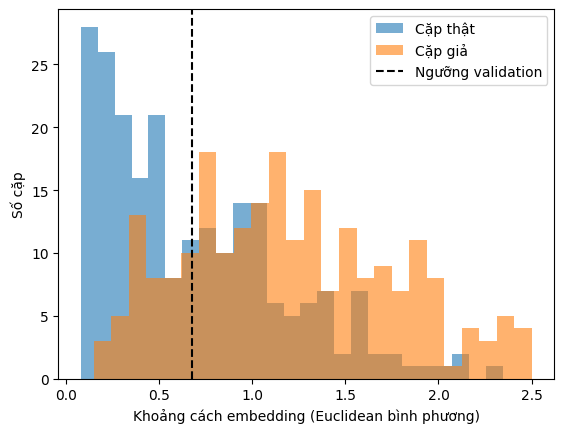

In [5]:
def pair_distances(dataset):
    distances, labels = [], []
    for (a, p, n), _ in dataset:
        ea = embedding(a, training=False).numpy()
        ep = embedding(p, training=False).numpy()
        en = embedding(n, training=False).numpy()
        distances.extend([
            np.sum((ea - ep) ** 2, axis=1),
            np.sum((ea - en) ** 2, axis=1),
        ])
        labels.extend([np.ones(len(ea)), np.zeros(len(ea))])
    return np.concatenate(distances), np.concatenate(labels).astype(int)


if MODEL_LOADED and THRESHOLD_PATH.is_file():
    with THRESHOLD_PATH.open(encoding="utf-8") as f:
        saved_threshold = json.load(f)
    if tuple(saved_threshold["image_size"]) != IMG_SIZE:
        raise ValueError("Kích thước ảnh trong file ngưỡng không khớp IMG_SIZE.")
    threshold = float(saved_threshold["threshold"])
    print(f"Đã tải ngưỡng: {threshold:.4f} từ {THRESHOLD_PATH}")
else:
    val_distance, val_label = pair_distances(val_ds)
    # ROC dùng điểm giống nhau = -distance (điểm lớn => giống hơn).
    fpr, tpr, thresholds = roc_curve(val_label, -val_distance, drop_intermediate=False)
    finite = np.flatnonzero(np.isfinite(thresholds))
    best = finite[np.argmax((tpr - fpr)[finite])]
    threshold = float(-thresholds[best])
    print(f"Ngưỡng từ validation: {threshold:.4f}")
    with THRESHOLD_PATH.open("w", encoding="utf-8") as f:
        json.dump({"threshold": threshold, "image_size": list(IMG_SIZE)}, f, indent=2)
    print(f"Đã lưu ngưỡng: {THRESHOLD_PATH}")

test_loss = siamese.evaluate(test_ds, verbose=0)
test_distance, test_label = pair_distances(test_ds)
test_prediction = (test_distance <= threshold).astype(int)
print(f"Test triplet loss: {test_loss:.4f}")
print(f"Test accuracy: {accuracy_score(test_label, test_prediction):.2%}")
print(f"Test ROC AUC: {roc_auc_score(test_label, -test_distance):.4f}")
print("Confusion matrix (hàng = nhãn thật, cột = dự đoán; thứ tự 0=giả, 1=thật):")
print(confusion_matrix(test_label, test_prediction, labels=[0, 1]))

plt.hist(test_distance[test_label == 1], bins=25, alpha=0.6, label="Cặp thật")
plt.hist(test_distance[test_label == 0], bins=25, alpha=0.6, label="Cặp giả")
plt.axvline(threshold, color="black", linestyle="--", label="Ngưỡng validation")
plt.xlabel("Khoảng cách embedding (Euclidean bình phương)")
plt.ylabel("Số cặp")
plt.legend()
plt.show()


## 5. Xem ảnh các cặp dự đoán đúng và sai

Hiển thị tối đa 4 cặp mỗi nhóm trên chính tập test đã đánh giá. Mỗi hàng gồm ảnh tham chiếu và ảnh cần kiểm tra, kèm nhãn thật, dự đoán và khoảng cách. Đổi `N_SHOW` để xem nhiều hơn. Chạy cell đánh giá test phía trên trước.


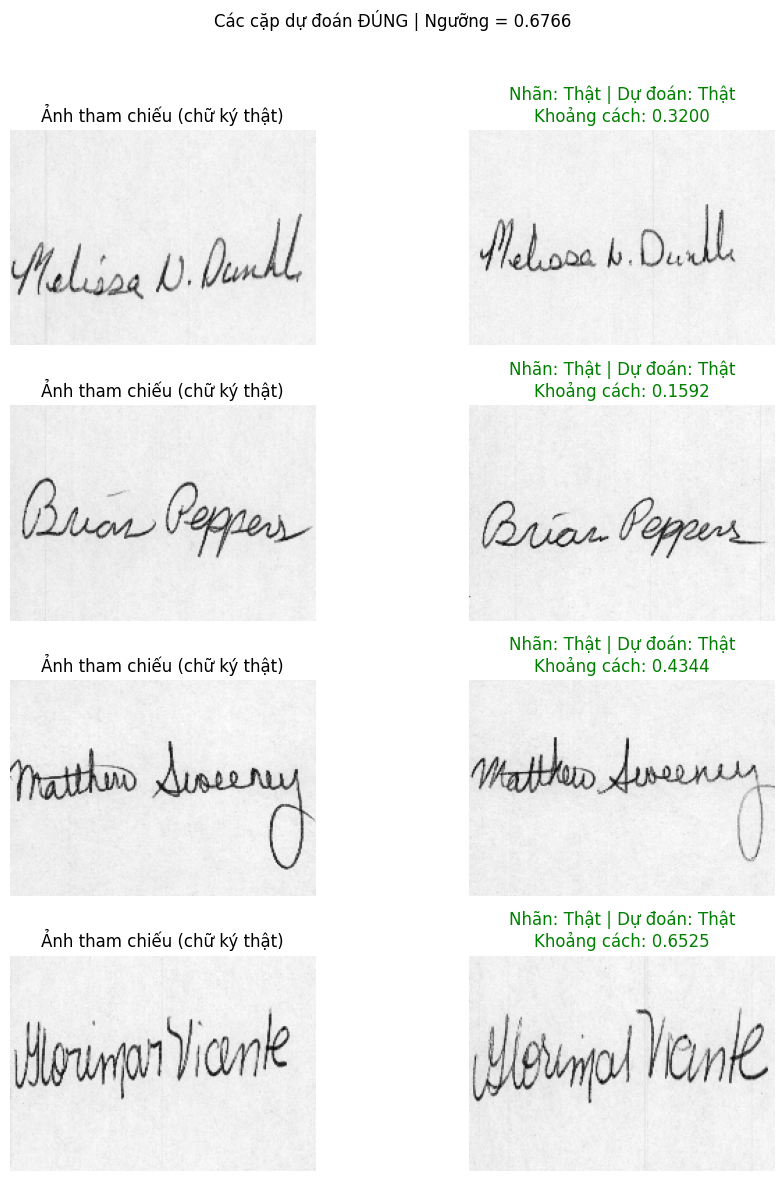

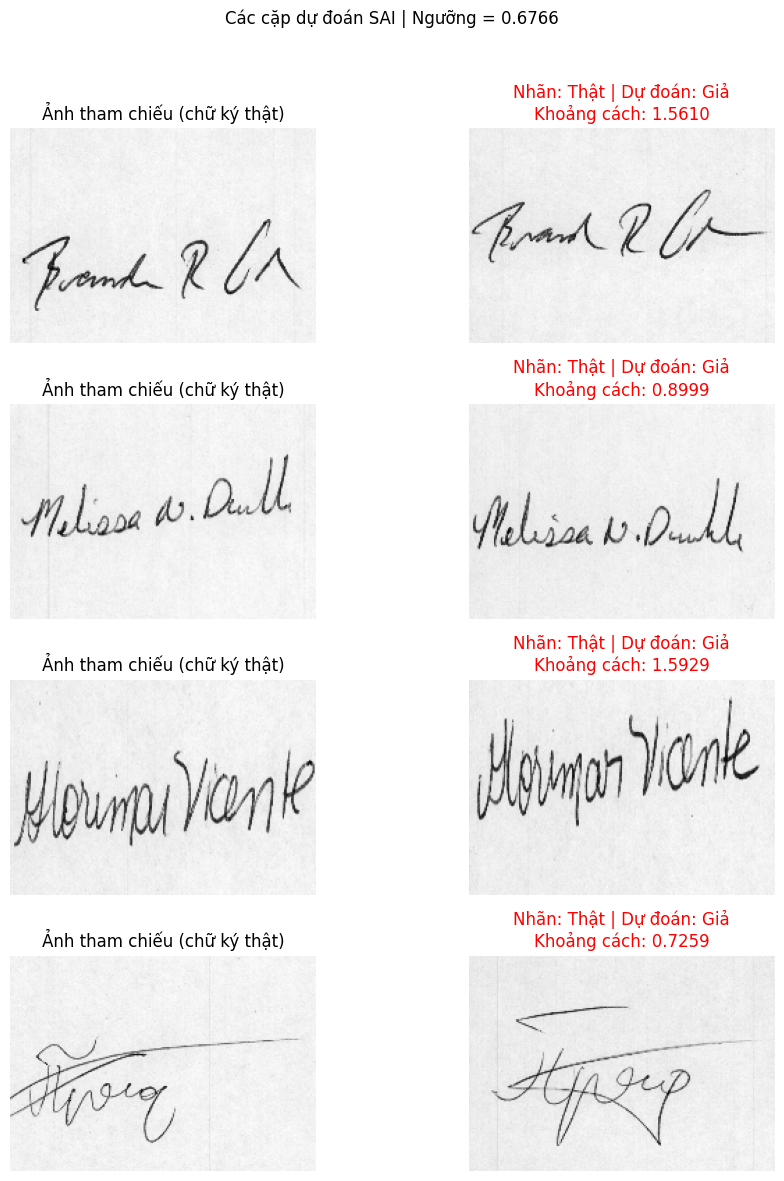

In [6]:
N_SHOW = 4
examples = {"ĐÚNG": [], "SAI": []}
index = 0

# Giữ cùng thứ tự với pair_distances: mỗi batch lấy (A,P) rồi (A,N).
# Dùng lại dự đoán test, không chọn lại ngưỡng.
for (a, p, n), _ in test_ds:
    for query in (p, n):
        for i in range(len(a)):
            label = int(test_label[index])
            prediction = int(test_prediction[index])
            distance = float(test_distance[index])
            group = "ĐÚNG" if prediction == label else "SAI"
            if len(examples[group]) < N_SHOW:
                examples[group].append((
                    a[i].numpy(), query[i].numpy(), label, prediction, distance
                ))
            index += 1
    if all(len(items) >= N_SHOW for items in examples.values()):
        break

for group, items in examples.items():
    if not items:
        print(f"Không có cặp dự đoán {group.lower()} trong tập test.")
        continue
    fig, axes = plt.subplots(len(items), 2, figsize=(10, 3 * len(items)), squeeze=False)
    fig.suptitle(f"Các cặp dự đoán {group} | Ngưỡng = {threshold:.4f}")
    for row, (reference, query, label, prediction, distance) in enumerate(items):
        axes[row, 0].imshow(reference.squeeze(), cmap="gray")
        axes[row, 0].set_title("Ảnh tham chiếu (chữ ký thật)")
        axes[row, 1].imshow(query.squeeze(), cmap="gray")
        actual = "Thật" if label == 1 else "Giả"
        predicted = "Thật" if prediction == 1 else "Giả"
        axes[row, 1].set_title(
            f"Nhãn: {actual} | Dự đoán: {predicted}\nKhoảng cách: {distance:.4f}",
            color="green" if group == "ĐÚNG" else "red",
        )
        for ax in axes[row]:
            ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## 6. Thử với hai ảnh

Hàm dưới đây dùng cùng resize và chuẩn hóa như preprocessing. Giá trị trả về là khoảng cách, không phải xác suất. Model được lưu ở bước train, ngưỡng được lưu ở bước validation; cả hai nằm trong thư mục `model/` để dùng lại trong lần chạy sau.


In [7]:
def load_signature(path):
    image = tf.io.decode_png(tf.io.read_file(str(path)), channels=1)
    return tf.image.resize(image, IMG_SIZE) / 255.0


def verify_signature(reference_path, query_path):
    images = tf.stack([load_signature(reference_path), load_signature(query_path)])
    vectors = embedding(images, training=False).numpy()
    distance = float(np.sum((vectors[0] - vectors[1]) ** 2))
    return {"distance": distance, "is_genuine": bool(distance <= threshold)}


writer_id = test_w[0]
reference = writers[writer_id]["org"][0]
print("Cặp thật:", verify_signature(reference, writers[writer_id]["org"][1]))
print("Cặp giả:", verify_signature(reference, writers[writer_id]["forg"][0]))


Cặp thật: {'distance': 1.9065574407577515, 'is_genuine': False}
Cặp giả: {'distance': 1.0933982133865356, 'is_genuine': False}
